# Black Friday Logistics Nightmare

**Objective:** Every Black Friday, warehouses get overwhelmed, products run out, and deliveries collapse under the surge. This project uses real Black Friday transaction data to answer three critical logistics questions:

- Who is buying, and where from?
- What products move the fastest?
- How much spending should we prepare for?




---

# Week 1 — Team Formation and Data Hunting

This week we formed our project team, selected our dataset, set up version control on GitHub, and got familiar with the core tools we will be using throughout the project: Pandas and NumPy.

## Why This Dataset?

Black Friday is the single busiest shopping day of the year. Warehouses, delivery networks, and retail logistics teams all strain under the spike in demand. A dataset of half a million real Black Friday transactions gives us enough volume to find genuine patterns — patterns that could help a logistics manager know exactly where to put extra staff, which product zones to restock first, and which delivery routes to reinforce.

## Dataset Source

The dataset was sourced from Kaggle's Black Friday Sales dataset. It contains 550,068 individual purchase transactions with demographic information about each customer and the product categories they purchased.


---

In [1]:
# Import all required libraries:
# pandas & numpy for data handling, matplotlib & seaborn for charts,
# scipy for statistics, and warnings to suppress unnecessary output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Black Friday dataset from a CSV file into a DataFrame
df = pd.read_csv('BlackFriday dataset.csv')

In [3]:
# Preview the first 5 rows to see what the data looks like
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [4]:
# Check the total size: number of rows (transactions) and columns (features)
df.shape

(550068, 12)

In [5]:
# List all column names in the dataset
df.columns.tolist()

['User_ID',
 'Product_ID',
 'Gender',
 'Age',
 'Occupation',
 'City_Category',
 'Stay_In_Current_City_Years',
 'Marital_Status',
 'Product_Category_1',
 'Product_Category_2',
 'Product_Category_3',
 'Purchase']

We successfully loaded the dataset and confirmed it contains 550,068 rows and 12 columns. The data structure is clear, and we are ready to inspect it more deeply in Week 2.

---

---

# Week 2 — Know Your Data

This week we take a proper "first impression" of the dataset. Before touching any values we want to understand the structure, the data types, the scale of missing values, and any obvious oddities.

The goal is to produce a First Impression Report that documents what we found before any cleaning begins.


## Data Types and Structure

In [6]:
# Show each column's data type and how many non-null (filled) values it has
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


The info summary shows us that three columns have non-integer dtypes. Gender, Age, City_Category, Stay_In_Current_City_Years, and Product_ID are stored as objects (strings). Product_Category_2 and Product_Category_3 have only partial data, which is visible from the lower non-null counts.

In [7]:
# Display the data type of every column
df.dtypes

User_ID                         int64
Product_ID                     object
Gender                         object
Age                            object
Occupation                      int64
City_Category                  object
Stay_In_Current_City_Years     object
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

---

## Statistical Summary of Numerical Columns

In [8]:
# Get summary statistics (count, mean, min, max, etc.) for numeric columns
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


The describe output tells us that the average purchase is around Rs 9,263 but the range is wide, from Rs 12 to Rs 23,961. This large spread is a warning signal for logistics planning — we cannot design a single fulfilment process for all orders.

In [9]:
# Get summary statistics for text/categorical columns (unique counts, top values)
df.describe(include='object')

,Product_ID,Gender,Age,City_Category,Stay_In_Current_City_Years
count,550068,550068,550068,550068,550068
unique,3631,2,7,3,5
top,P00265242,M,26-35,B,1
freq,1880,414259,219587,231173,193821


The object columns show us the unique values in each categorical field. Age has 7 distinct groups, City_Category has 3 tiers, and Stay_In_Current_City_Years has 5 values. Product_ID has high cardinality (3,631 unique products).

---

## Missing Values

In [10]:
# Count how many values are missing in each column
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

Product_Category_2 and Product_Category_3 have missing values. This is not a data error — most products simply belong to only one or two categories. A product with no second or third category is just a simpler product.

In [11]:
# Show missing values as a percentage of the total dataset
(df.isnull().sum() / len(df) * 100).round(2)

User_ID                        0.00
Product_ID                     0.00
Gender                         0.00
Age                            0.00
Occupation                     0.00
City_Category                  0.00
Stay_In_Current_City_Years     0.00
Marital_Status                 0.00
Product_Category_1             0.00
Product_Category_2            31.57
Product_Category_3            69.67
Purchase                       0.00
dtype: float64

Product_Category_2 is missing in about 31.5% of rows. Product_Category_3 is missing in about 69.7% of rows. These high rates tell us that the majority of Black Friday purchases are single-category or dual-category products.

---

## Duplicate Rows

In [12]:
# Check if there are any completely duplicate rows in the dataset
df.duplicated().sum()

0

There are no fully duplicate rows in the dataset. Each transaction row is unique even if the same customer appears multiple times — because each row is a different product purchase.

---

## Unique Values per Column

In [13]:
# Count the number of unique values in each column
df.nunique()

User_ID                        5891
Product_ID                     3631
Gender                            2
Age                               7
Occupation                       21
City_Category                     3
Stay_In_Current_City_Years        5
Marital_Status                    2
Product_Category_1               20
Product_Category_2               17
Product_Category_3               15
Purchase                      18105
dtype: int64

---

## First Impression Report

After inspecting the raw dataset, here are the key findings before we do any cleaning:

The dataset is large at 550,068 transactions and mostly clean. The only missing values are in Product_Category_2 (31.5%) and Product_Category_3 (69.7%), which represent optional secondary and tertiary categories. These missing values have a clear business meaning — they are not errors.

The Purchase column has an extremely wide range (Rs 12 to Rs 23,961), suggesting that Black Friday shopping spans from impulse buys to major household purchases. This will have implications for how we plan warehouse zones.

There are no duplicates, and all identifier columns (User_ID, Product_ID) are present for every row.

The dataset is ready for cleaning in Week 3.

---

# Week 3 — The Cleaning Sprint

This week we handle missing values and detect outliers. Our cleaning philosophy for this dataset is conservative: we retain all rows, we replace missing values with meaningful defaults, and we detect outliers using the IQR method but keep them in place because they represent real high-value customers.

## Missing Value Strategy

Product_Category_2 and Product_Category_3 are missing when a product does not have a second or third category. Replacing these with 0 is the correct choice — it does not introduce any false information, and it signals to the model that no additional category was purchased.

---

In [14]:
# Make a copy of the original DataFrame so we never modify the raw data
df_clean = df.copy()

In [15]:
# Replace missing values in Product_Category_2 with 0
# (0 means the product has no secondary category — not an error)
df_clean['Product_Category_2'] = df_clean['Product_Category_2'].fillna(0)

In [16]:
# Replace missing values in Product_Category_3 with 0
# (same logic — 0 = product has no third category)
df_clean['Product_Category_3'] = df_clean['Product_Category_3'].fillna(0)

In [17]:
# Verify that all missing values are now filled (should show all zeros)
df_clean.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

All missing values have been filled. No rows were dropped. Every transaction record is preserved for analysis.

---

## Outlier Detection using the IQR Method

We use the IQR (Interquartile Range) method to detect outliers in the Purchase column. The IQR method is preferred over Z-score for this dataset because Purchase is right-skewed — it is not normally distributed — and the Z-score assumes normality.

The IQR method defines outliers as values below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR. We will detect these, show them in a boxplot, but keep all rows intact because high spenders are real customers, not data errors.


In [18]:
# Detect outliers in the Purchase column using the IQR method:
# Q1 = 25th percentile, Q3 = 75th percentile, IQR = Q3 - Q1
# Outliers are anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
Q1 = df_clean['Purchase'].quantile(0.25)
Q3 = df_clean['Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [19]:
# Count how many transactions are flagged as statistical outliers
outliers = df_clean[(df_clean['Purchase'] < lower_bound) | (df_clean['Purchase'] > upper_bound)]
outliers.shape[0]

2677

The IQR method flagged a number of rows as statistical outliers in the Purchase column. Before deciding what to do, let us visualise the distribution.

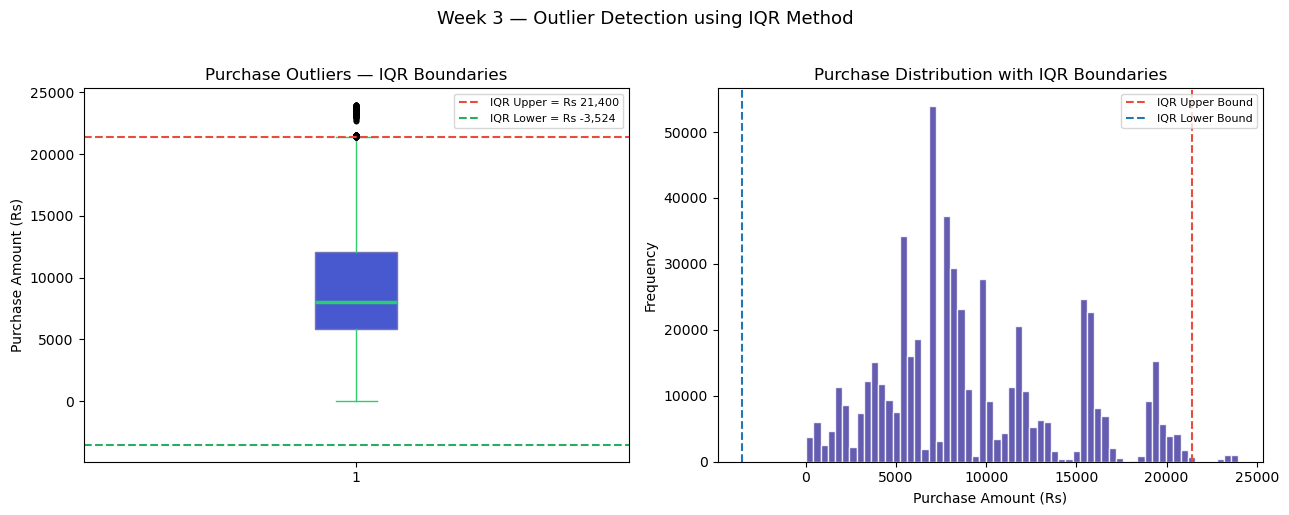

In [20]:
# Draw a boxplot and histogram to visualize the Purchase distribution
# Red dashed line = IQR upper bound (outlier cutoff)
# Green dashed line = IQR lower bound
# Dots above the red line = outlier transactions (real high-value customers we keep them)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
axes[0].boxplot(df_clean['Purchase'], patch_artist=True,
                boxprops=dict(facecolor="#4858CF", color="#7872B8"),
                medianprops=dict(color='#2ECC71', linewidth=2.5),
                whiskerprops=dict(color='#2ECC71'),
                capprops=dict(color='#2ECC71'),
                flierprops=dict(marker='o', color='#FF6B6B', alpha=0.3, markersize=3))
axes[0].axhline(upper_bound, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'IQR Upper = Rs {upper_bound:,.0f}')
axes[0].axhline(lower_bound, color='#27AE60', linestyle='--', linewidth=1.5, label=f'IQR Lower = Rs {lower_bound:,.0f}')
axes[0].set_title('Purchase Outliers — IQR Boundaries')
axes[0].set_ylabel('Purchase Amount (Rs)')
axes[0].legend(fontsize=8)

# Histogram with bounds
axes[1].hist(df_clean['Purchase'], bins=60, color="#493FA3", edgecolor='white', alpha=0.85)
axes[1].axvline(upper_bound, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'IQR Upper Bound')
axes[1].axvline(lower_bound, linestyle='--', linewidth=1.5, label=f'IQR Lower Bound')
axes[1].set_title('Purchase Distribution with IQR Boundaries')
axes[1].set_xlabel('Purchase Amount (Rs)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

plt.suptitle('Week 3 — Outlier Detection using IQR Method', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The boxplot and histogram confirm that the Purchase column is right-skewed. The red dashed line marks the IQR upper boundary. Points above it are classified as statistical outliers.

However, we are keeping all these records. A customer who spends Rs 20,000 on Black Friday is a real, valuable customer — not a data error. Removing these rows would mean planning the logistics with no preparation for the highest-spending segment.

The logistics implication is the opposite: these outlier customers need the most attention. They are placing the heaviest, most valuable orders and need priority fulfilment.

We detect the outliers, we document them, and we move forward with all 550,068 rows intact.

---

In [21]:
# Confirm that all 550,068 rows are still in the dataset (no rows were dropped)
df_clean.shape

(550068, 12)

All rows are preserved. The dataset is now clean and ready for exploratory analysis.


---

# Week 4 — EDA Deep Dive

This week we use visualisations to discover the patterns hidden in the data. Every chart we draw answers a specific logistics question. We start with univariate analysis — understanding one variable at a time — and then move into bivariate analysis to discover relationships between pairs of variables.


## Univariate Analysis

Univariate analysis looks at one variable at a time. The goal is to understand the shape, range, and distribution of each column before we start comparing variables against each other.



### 4.1 — Purchase Amount Distribution

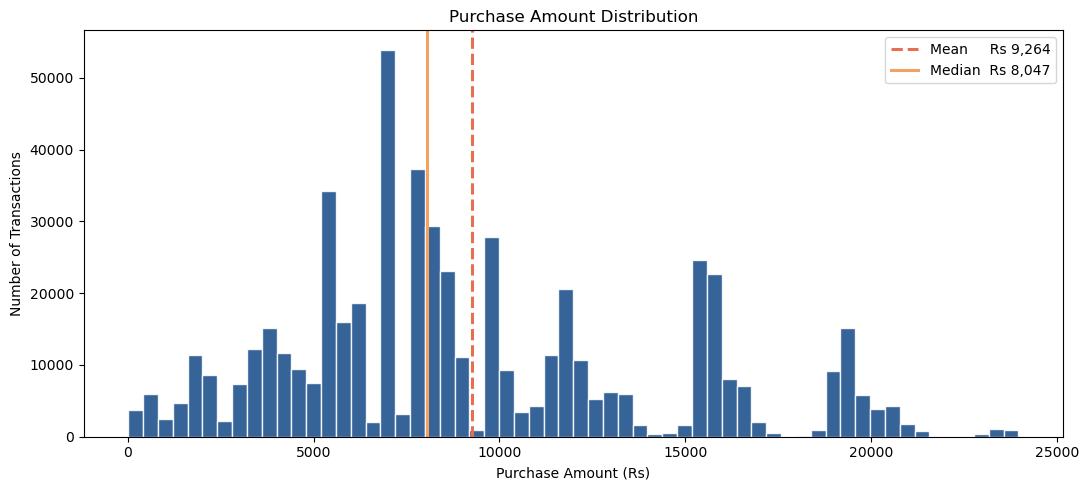

In [22]:
# Plot the distribution of all purchase amounts
# Orange dashed line = mean, solid line = median
# Right-skewed = most purchases are mid-range, with a long tail of expensive ones
fig, ax = plt.subplots(figsize=(11, 5))

avg    = df_clean['Purchase'].mean()
median = df_clean['Purchase'].median()

ax.hist(df_clean['Purchase'], bins=60, color="#1B4F8A", edgecolor='white', alpha=0.88)
ax.axvline(avg,    color='#E76F51', linewidth=2.2, linestyle='--', label=f'Mean     Rs {avg:,.0f}')
ax.axvline(median, color='#F4A261', linewidth=2.2, linestyle='-',  label=f'Median  Rs {median:,.0f}')
ax.set_title('Purchase Amount Distribution')
ax.set_xlabel('Purchase Amount (Rs)')
ax.set_ylabel('Number of Transactions')
ax.legend()
plt.tight_layout()
plt.show()


The distribution is right-skewed. Most Black Friday transactions fall between Rs 5,000 and Rs 12,000, but a long tail of high-value purchases stretches toward Rs 23,000. The mean sits higher than the median, confirming this skew.

For logistics this means we cannot plan a single fulfilment lane for all orders. We need a standard lane for the majority of mid-range purchases and a dedicated express lane for the high-spend orders that sit in that tail.

---

### 4.2 — Gender Split

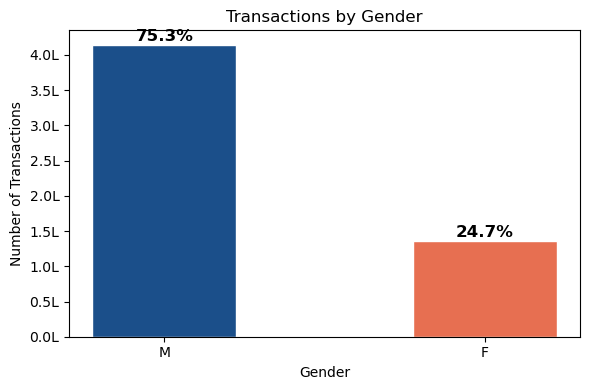

In [23]:
# Count the number of transactions by gender and calculate the percentage split
# Bar chart shows how purchases are divided between male and female shoppers
counts = df_clean['Gender'].value_counts()
pct    = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
colors_gender = ['#E76F51' if g == 'F' else '#1B4F8A' for g in counts.index]
bars = ax.bar(counts.index, counts.values, color=colors_gender, edgecolor='white', width=0.45)
for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{p:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Transactions by Gender')
ax.set_ylabel('Number of Transactions')
ax.set_xlabel('Gender')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e5:.1f}L'))
plt.tight_layout()
plt.show()


75% of all Black Friday transactions come from male shoppers. Female shoppers account for only 25%.

For logistics, this means products popular with men — electronics, gadgets, sports gear — will dominate order volume. The warehouse picking zones for male-oriented products need the most staff, the most floor space, and the fastest restock alerts.

---

### 4.3 — Age Group Distribution

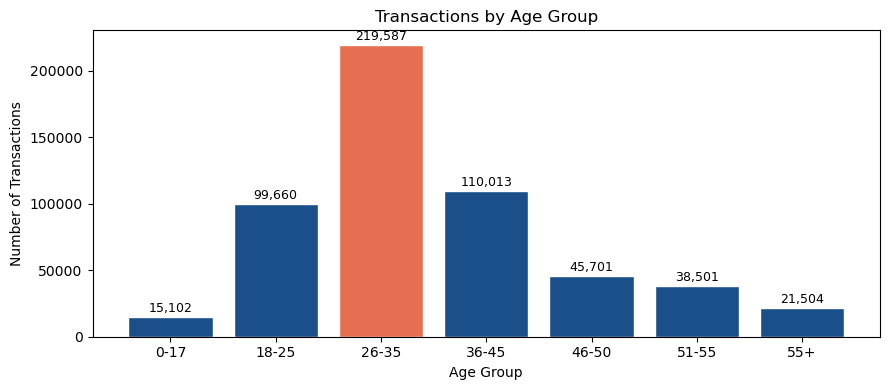

In [24]:
# Count transactions for each age group, sorted by age
# The age group with the highest count is highlighted in orange
counts = df_clean['Age'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
max_idx = counts.idxmax()
colors = ["#E76F51" if age == max_idx else "#1B4F8A" for age in counts.index]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Transactions by Age Group')
ax.set_ylabel('Number of Transactions')
ax.set_xlabel('Age Group')
plt.tight_layout()
plt.show()


The 26–35 age group has the highest number of transactions by a wide margin, followed by 36–45 and 18–25. The 0–17 and 55+ groups are the smallest segments.

For logistics, the 26–35 group is in their peak earning years and buys the most frequently. Whatever product categories this group prefers need the highest stock levels and the fastest picking throughput on Black Friday.

---

### 4.4 — City Tier Distribution

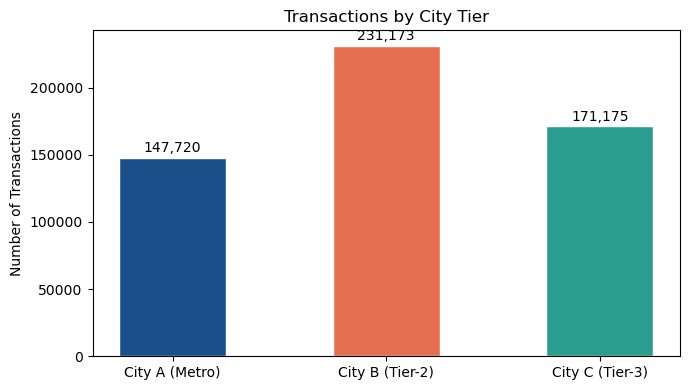

In [25]:
# Count transactions by city tier: A=Metro, B=Tier-2, C=Tier-3
# Reveals which city type drives the most Black Friday purchases
counts = df_clean['City_Category'].value_counts().reindex(['A','B','C'])
labels = ['City A (Metro)', 'City B (Tier-2)', 'City C (Tier-3)']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts.values, color=['#1B4F8A','#E76F51','#2A9D8F'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Transactions by City Tier')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()


City B (Tier-2 cities) generates more transactions than City A and City C combined. This is unexpected — you might assume that metro cities (City A) would dominate, but Tier-2 cities show the highest purchase activity.

The logistics implication is significant: the distribution centre serving Tier-2 cities faces the heaviest Black Friday load. It needs the most workers, the most stock, and the most delivery vehicles allocated to it.

---

### 4.5 — Product Category 1 Distribution

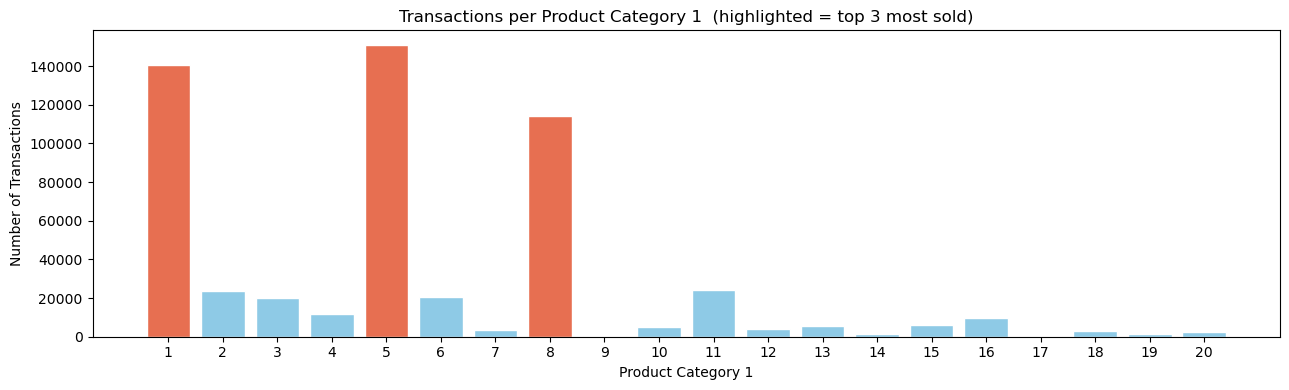

In [26]:
# Count how many transactions belong to each Product Category 1 value
# Top 3 most-purchased categories are highlighted in orange
counts   = df_clean['Product_Category_1'].value_counts().sort_index()
top3_idx = counts.nlargest(3).index
colors   = ["#E76F51" if i in top3_idx else "#8ECAE6" for i in counts.index]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white')
ax.set_title('Transactions per Product Category 1  (highlighted = top 3 most sold)')
ax.set_xlabel('Product Category 1')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()


A small number of product categories account for the vast majority of transactions. The top three categories are highlighted in dark blue and dominate all others by a significant margin.

For logistics, these are the hottest zones in the warehouse. They need dedicated picking aisles with the fastest conveyor throughput, automatic low-stock alerts, and the highest replenishment priority on Black Friday.

---

### 4.6 — Stay in City Distribution

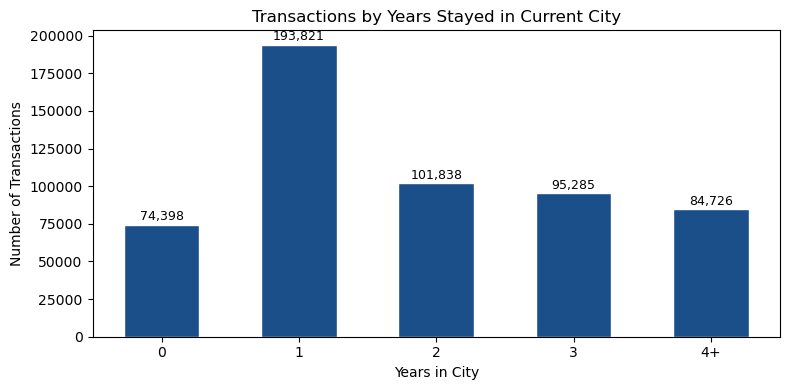

In [27]:
# Count transactions based on how many years customers have lived in their current city
# Helps understand buying behavior of new vs long-term residents
counts = df_clean['Stay_In_Current_City_Years'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(counts.index, counts.values, color="#1B4F8A", edgecolor='white', width=0.55)
for bar, val in zip(ax.patches, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Transactions by Years Stayed in Current City')
ax.set_xlabel('Years in City')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()


Customers who have stayed in the city for 1 year make the most transactions. New residents (0 years) and long-term residents (4+ years) contribute meaningful volume as well.

This tells us something useful about buying behaviour: people new to a city are likely to buy home-setup products like appliances and furniture, while long-term residents may be upgrading existing products.

---

## Bivariate Analysis

Bivariate analysis compares two variables at the same time to discover relationships between them.

---

### 4.7 — Purchase Amount by Gender

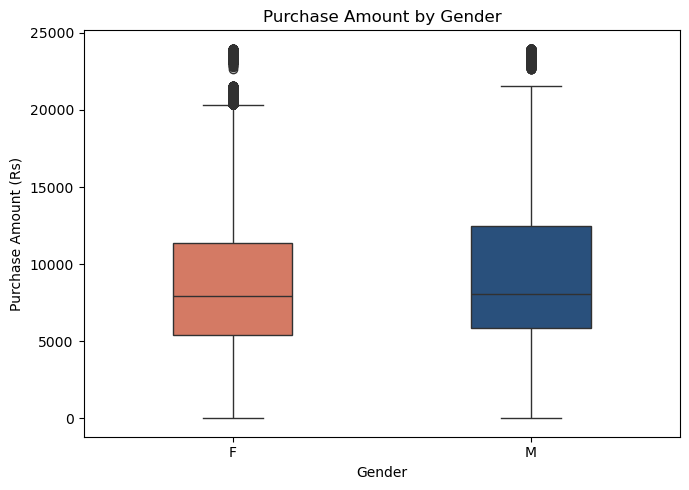

In [28]:
# Boxplot comparing purchase amounts for male vs female shoppers
# Shows median and spread of spending by gender
fig, ax = plt.subplots(figsize=(7, 5))
palette_gender = {'F': '#E76F51', 'M': '#1B4F8A'}
sns.boxplot(data=df_clean, x='Gender', y='Purchase',
            palette=palette_gender, order=['F','M'], width=0.4, ax=ax)
ax.set_title('Purchase Amount by Gender')
ax.set_ylabel('Purchase Amount (Rs)')
ax.set_xlabel('Gender')
plt.tight_layout()
plt.show()


Male shoppers spend slightly more per transaction than female shoppers. The median and interquartile range are both marginally higher for men, though the difference is not dramatic.

The key takeaway for logistics: male-targeted product zones carry both higher volume AND higher spend per shipment. These zones need priority restock on Black Friday.

---

### 4.8 — Purchase Amount by City Tier

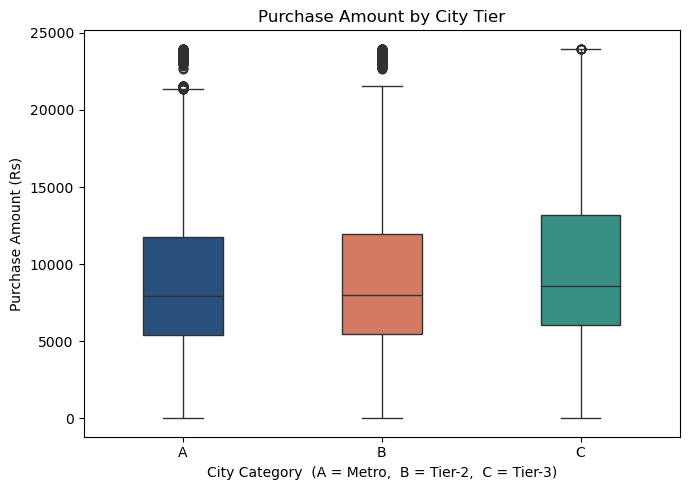

In [29]:
# Boxplot comparing purchase amounts across city tiers (A, B, C)
# Shows which city type spends more per transaction on average
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_clean, x='City_Category', y='Purchase',
            palette={'A':'#1B4F8A','B':'#E76F51','C':'#2A9D8F'},
            order=['A','B','C'], width=0.4, ax=ax)
ax.set_title('Purchase Amount by City Tier')
ax.set_ylabel('Purchase Amount (Rs)')
ax.set_xlabel('City Category  (A = Metro,  B = Tier-2,  C = Tier-3)')
plt.tight_layout()
plt.show()


City C (Tier-3 cities) has the highest median purchase per transaction, even though it generates fewer orders than City B. City A and City B have very similar spend distributions.

The logistics implication here is counter-intuitive: smaller cities spend more per order. Warehouses serving Tier-3 cities should stock more premium, higher-value products — even if total shipment volume is lower.

---

### 4.9 — Purchase Amount by Age Group

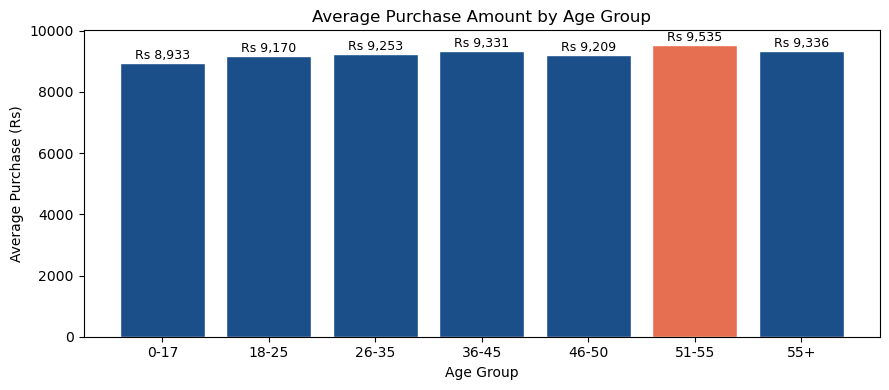

In [30]:
# Calculate the average purchase amount for each age group
# Bar chart highlights the highest-spending age group in orange
age_avg = df_clean.groupby('Age')['Purchase'].mean().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
top_age = age_avg.idxmax()
colors  = ["#E76F51" if age == top_age else "#1B4F8A" for age in age_avg.index]
bars    = ax.bar(age_avg.index, age_avg.values, color=colors, edgecolor='white')
for bar, val in zip(bars, age_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'Rs {val:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Average Purchase Amount by Age Group')
ax.set_ylabel('Average Purchase (Rs)')
ax.set_xlabel('Age Group')
plt.tight_layout()
plt.show()


Older age groups (55+) have the highest average spend per transaction, even though they buy less frequently. The 51–55 group is the second highest spender per order.

For logistics, premium and high-end product zones need priority pick areas to serve older, high-spending customers — even if they represent a smaller share of total volume.

---

### 4.10 — City Tier and Gender Combined Volume

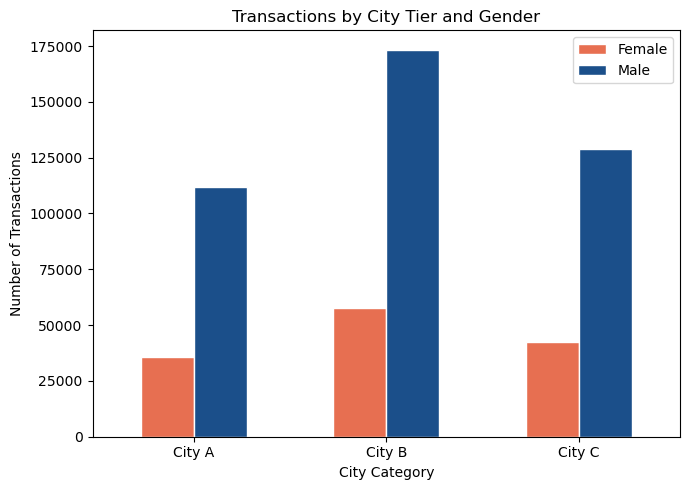

In [31]:
# Group transactions by both city tier and gender, then count them
# Grouped bar chart shows which city+gender combination buys the most
pivot = df_clean.groupby(['City_Category','Gender']).size().unstack()

fig, ax = plt.subplots(figsize=(7, 5))
pivot.plot(kind='bar', color=["#E76F51", "#1B4F8A"], edgecolor='white', ax=ax, width=0.55)
ax.set_title('Transactions by City Tier and Gender')
ax.set_ylabel('Number of Transactions')
ax.set_xlabel('City Category')
ax.set_xticklabels(['City A', 'City B', 'City C'], rotation=0)
ax.legend(['Female','Male'])
plt.tight_layout()
plt.show()


City B + Male is the single largest city-gender combination by a wide margin. This combination represents the primary logistics bottleneck on Black Friday.

The City B warehouse, specifically the male product zone, needs the most staff, the fastest conveyor belts, and the highest restock frequency of any zone in the entire operation.

---

### 4.11 — Revenue by Product Category

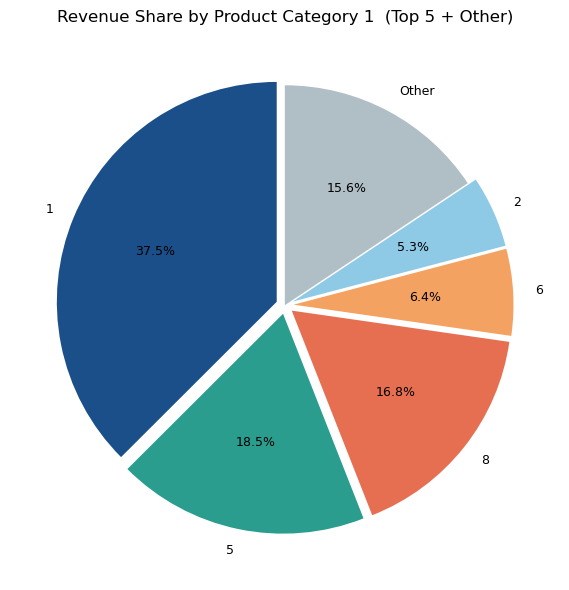

In [32]:
# Calculate total revenue (sum of purchases) for each product category
# Pie chart shows the top 5 revenue categories + all others as 'Other'
cat_rev  = df_clean.groupby('Product_Category_1')['Purchase'].sum().sort_values(ascending=False)
top5     = cat_rev.head(5)
other    = pd.Series({'Other': cat_rev.iloc[5:].sum()})
pie_data = pd.concat([top5, other])

palette_pie = ['#1B4F8A','#2A9D8F','#E76F51','#F4A261','#8ECAE6','#B0BEC5']

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(pie_data.values, labels=pie_data.index.astype(str),
                                   autopct='%1.1f%%', startangle=90,
                                   colors=palette_pie, explode=[0.04]*5+[0],
                                   textprops={'fontsize': 9})
ax.set_title('Revenue Share by Product Category 1  (Top 5 + Other)')
plt.tight_layout()
plt.show()


The top 5 product categories alone generate the majority of total Black Friday revenue. These categories are not just high in transaction volume — they are high in spend per transaction as well.

For logistics, if these top revenue categories run out of stock or face a packing delay, revenue loss is immediate and severe. These zones need dedicated buffer stock, separate quality-check stations, and the fastest dispatch priority.

---

### 4.12 — Correlation Matrix

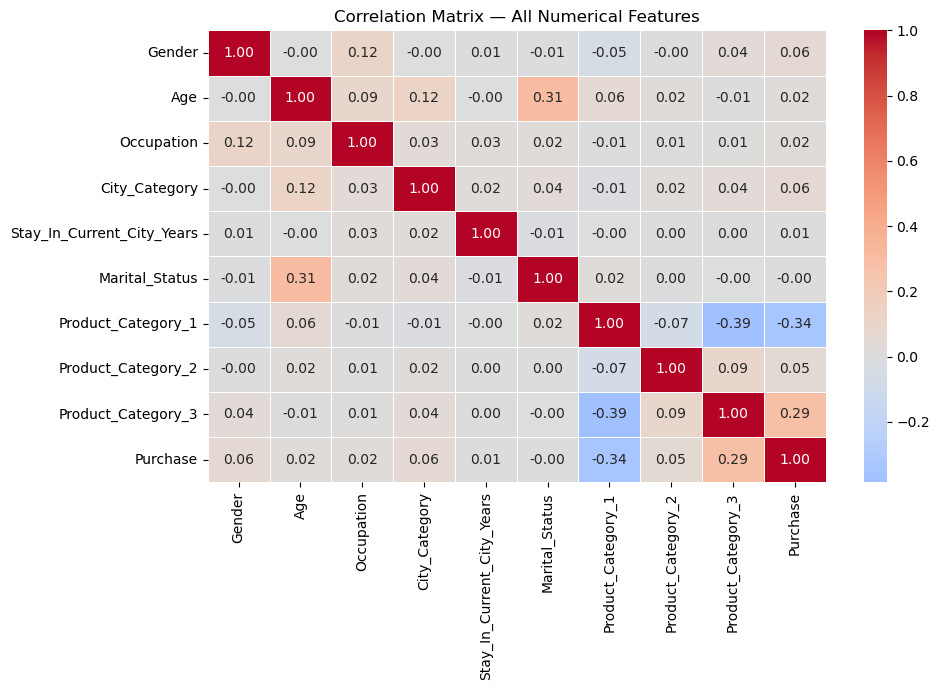

In [33]:
# Temporarily encode text columns as numbers so we can compute correlations
# Then plot a heatmap showing how strongly each pair of features is related
# Values near 1 or -1 = strong correlation; near 0 = weak/no correlation
df_corr = df_clean.copy()
from sklearn.preprocessing import LabelEncoder

for col in ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']:
    le_col = LabelEncoder()
    df_corr[col] = le_col.fit_transform(df_corr[col].astype(str))

num_cols = ['Gender','Age','Occupation','City_Category','Stay_In_Current_City_Years',
            'Marital_Status','Product_Category_1','Product_Category_2','Product_Category_3','Purchase']

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_corr[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — All Numerical Features')
plt.tight_layout()
plt.show()


No single column is a dominant predictor of Purchase on its own. Product_Category_1 has a moderate negative correlation with Purchase — lower category numbers tend to correspond to more expensive product types. Product_Category_2 and Product_Category_3 are positively correlated, which makes sense since they often appear together in multi-category products.

Demographics like Gender, Age, and Occupation show only weak individual correlations with Purchase. This tells us that meaningful predictions will require combinations of features — not a single column in isolation. This is what we will build in Week 6.

---

## Week 4 Summary

Key patterns we discovered this week:

The core Black Friday customer is male, aged 26–35, from a Tier-2 city (City B). This combination drives the highest transaction volume in the entire dataset.

City C customers spend more per order on average despite fewer total transactions. This warrants stocking premium products in Tier-3 distribution points.

A handful of product categories dominate both volume and revenue. Losing stock in those zones on Black Friday means immediate, serious revenue loss.

The Purchase distribution is right-skewed, meaning we need to treat outliers carefully — they are real high-value customers, not noise.
